✅ Dataset loaded successfully!
  Transaction_ID Product_ID Product_Category   Price  Discount Customer_ID  \
0        T180787      P8392            Books   15.58      0.46      C66501   
1        T750990      P5778            Books   62.00     12.27      C12853   
2        T627626      P5136   Home & Kitchen  958.29     61.67      C74523   
3        T602068      P5945      Electronics  657.01    135.43      C31822   
4        T286338      P8427   Home & Kitchen  147.16     22.23      C84859   

   Customer_Age Customer_Gender Purchase_Timestamp Payment_Method  \
0            49            Male    3/31/2024 14:16    Credit Card   
1            26           Other   02-10-2024 09:31     Debit Card   
2            23            Male    5/23/2024 13:04     Debit Card   
3            33          Female     6/22/2024 9:20         PayPal   
4            40           Other     5/16/2024 6:15    Credit Card   

  Shipping_Type  Review_Rating  Purchase_Probability  
0       Express              1

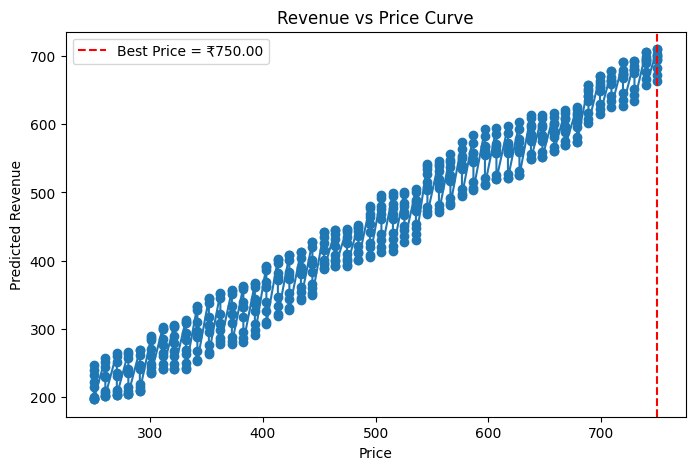

In [8]:
# =====================================
# Dynamic Pricing Optimization Project
# =====================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# =====================================
# Step 2: Load Your Dataset
# (<<<--- This is where you add your file --->>>)

# Give your dataset path here:
file_path = "/content/ecommerce_dynamic_pricing_dataset.csv"   # 👈 put your CSV file name here
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print(df.head())

# =====================================
# Step 3: Preprocess Data
# Create a target column: expected sales or revenue
# We’ll use Purchase_Probability × (Price - Discount) as an estimate of actual sales revenue

df['Expected_Revenue'] = (df['Price'] - df['Discount']) * df['Purchase_Probability']

# Drop unnecessary columns
df = df.drop(['Transaction_ID', 'Customer_ID', 'Purchase_Timestamp', 'Product_ID'], axis=1)

# Convert categorical columns to numeric (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Product_Category', 'Customer_Gender', 'Payment_Method', 'Shipping_Type'], drop_first=True)

# Define features and target
X = df.drop(['Expected_Revenue'], axis=1)
y = df['Expected_Revenue']

# =====================================
# Step 4: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================
# Step 5: Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Save Model
joblib.dump(model, "pricing_model.pkl")
print("✅ Model saved as pricing_model.pkl")

# =====================================
# Step 6: Dynamic Price Optimization Function
def optimize_price(model, base_price, discount_range, product_info):
    prices = np.linspace(base_price * 0.5, base_price * 1.5, 50)
    revenues = []

    for p in prices:
        for d in discount_range:
            features = product_info.copy()
            features['Price'] = p
            features['Discount'] = d

            # Create a DataFrame with the same columns as the training data
            sample = pd.DataFrame([features], columns=X.columns)

            # Ensure all columns have a value (fill missing with 0)
            sample = sample.fillna(0)

            predicted_revenue = model.predict(sample)[0]
            revenues.append((p, d, predicted_revenue))

    best_combo = max(revenues, key=lambda x: x[2])
    return best_combo, revenues

# =====================================
# Step 7: Example Use
# Choose one product type and customer info

# Create a dictionary with example values for the core features
example = {
    'Price': 500,
    'Discount': 50,
    'Customer_Age': 30,
    'Review_Rating': 4,
    'Purchase_Probability': 1,
    'Product_Category_Electronics': 1, # Example: Product is Electronics
    'Customer_Gender_Other': 0, # Example: Customer gender is not Other (assuming Male or Female from the original data or setting it based on need)
    'Payment_Method_Debit Card': 0, # Example: Payment method is not Debit Card
    'Payment_Method_Net Banking': 0, # Example: Payment method is not Net Banking
    'Payment_Method_PayPal': 0, # Example: Payment method is not PayPal
    'Shipping_Type_Standard': 0, # Example: Shipping type is not Standard
    'Shipping_Type_Express': 1, # Example: Shipping type is Express
}


discounts = np.linspace(0, 100, 10)
best_combo, all_results = optimize_price(model, base_price=500, discount_range=discounts, product_info=example)

print(f"\n💰 Optimal Price: ₹{best_combo[0]:.2f}")
print(f"💸 Optimal Discount: ₹{best_combo[1]:.2f}")
print(f"📈 Expected Revenue: ₹{best_combo[2]:.2f}")

# =====================================
# Step 8: Visualize Price vs Revenue
prices = [r[0] for r in all_results]
revenues = [r[2] for r in all_results]

plt.figure(figsize=(8, 5))
plt.plot(prices, revenues, marker='o')
plt.axvline(best_combo[0], color='r', linestyle='--', label=f'Best Price = ₹{best_combo[0]:.2f}')
plt.title("Revenue vs Price Curve")
plt.xlabel("Price")
plt.ylabel("Predicted Revenue")
plt.legend()
plt.show()